# **LICENTA**

- Setul de date este un set de pe
platforma Kaggle cu aproximativ 90k recenzii pentru top 250 filme din anul 2024 de pe Letterboxd. Am ales acest set pentru relevanta sa in sarcinile de procesare a limbajului natural, intrucat recenziile sunt relativ scurte si contin opinii subiective.

- Problema este una de clasificare multi-clasa, in care, pe baza textului unui review , modelul trebuie sa prezica filmul la care se refera. Variabila de intrare este textul review-ului, iar variabila tinta este titlul filmului in format numeric(movie label).

1. verificare/citire set de date


In [ ]:
import pandas as pd

df = pd.read_csv("reviews_clean.csv")

df.head()

,Number,Review,Rating,Date,Status,Movie,language
0,0,I am an idiot. Why is it that I still dread wa...,5.0,01 Dec 2013,Watched,harakiri,en
1,1,honor in the individual is virtue honor in a s...,5.0,18 Jan 2022,NaN,harakiri,en
2,3,God damn what an impeccable film. Not dated in...,5.0,21 Jun 2021,Watched,harakiri,en
3,4,95First thing's first: giving a big thanks to ...,5.0,06 Sep 2020,Watched,harakiri,en
4,5,Probably the greatest film ever.. a film about...,5.0,14 Apr 2020,Watched,harakiri,en


Vad ca exista recenzii unde utilizatorii au lasat un scor inainte de a scrie un comentariu, cum ar fi numarul 95 la cea de-a 5-a recenzie. Voi sterge aceste numere, voi verifica daca exista duplicate si voi pastra doar review-urile cu minim 20 de caractere pentru a evita zgomotul.

In [ ]:
import re

df['Review'] = df['Review'].str.replace(r'^\d{2,3}(?=[A-Za-z])', '', regex=True).str.strip()
df = df.drop_duplicates(subset=['Review', 'Movie'], keep='first')
df = df[df['Review'].str.len() >= 20]


NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75178 entries, 0 to 76466
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Number    75178 non-null  int64  
 1   Review    75178 non-null  object 
 2   Rating    75178 non-null  float64
 3   Date      75178 non-null  object 
 4   Status    72573 non-null  object 
 5   Movie     75178 non-null  object 
 6   language  75178 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 4.6+ MB


Am facut o distributie a notelor, pentru a intelege setul de date. Intrucat setul contine top 250 filme din anul 2024, extista o majoritate de scor maxim, ceea ce inseamna ca majoritatea review-urilor contin cuvinte pozitive, deci modelul va invata mai bine pe un input format din cuvinte cu conotatie pozitiva.


/tmp/ipykernel_2019/390287501.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis')


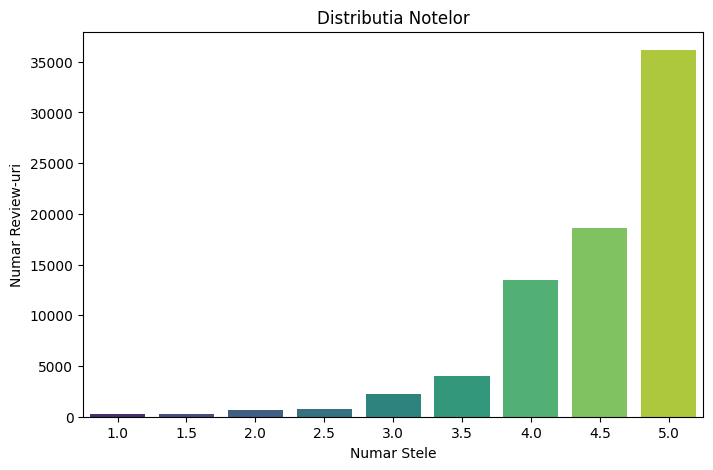

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('reviews_clean.csv')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Rating', palette='viridis')
plt.title('Distributia Notelor')
plt.xlabel('Numar Stele')
plt.ylabel('Numar Review-uri')
plt.show()

Deoarece majoritatea are macar 4,5 stele, voi considera ca toate recenziile de la 4 stele in jos au conotatii negative, iar restul conotatii pozitive.

/tmp/ipykernel_2019/2261268447.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


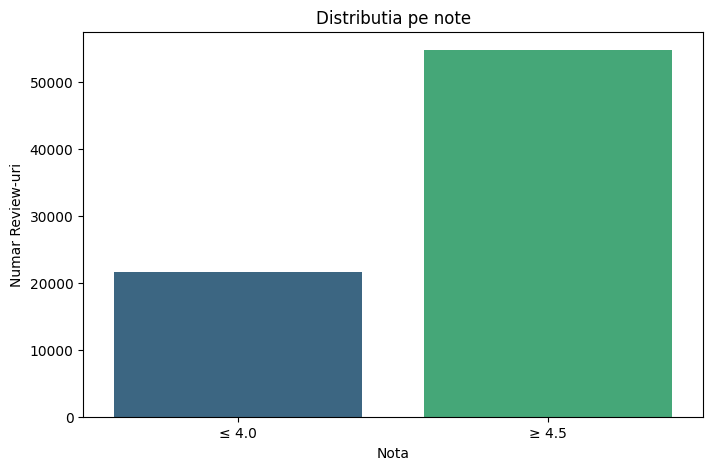

label
1    54781
0    21686
Name: count, dtype: int64

Procentaje:
label
1    71.6
0    28.4
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('reviews_clean.csv')
df['label'] = df['Rating'].apply(lambda x: 0 if x <= 4.0 else 1)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distributia pe note')
plt.xlabel('Nota')
plt.ylabel('Numar Review-uri')
plt.xticks([0, 1], ['≤ 4.0', '≥ 4.5'])
plt.show()

print(df['label'].value_counts())
print(f"\nProcentaje:")
print(df['label'].value_counts(normalize=True).mul(100).round(1))

- m am asigurat ca toate review urile sunt in engleza dupa filtrare

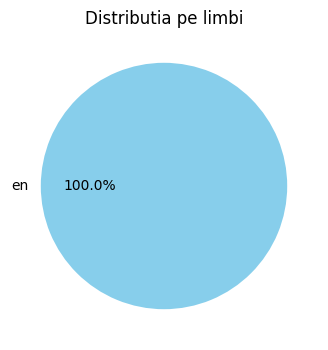

In [ ]:
plt.figure(figsize=(6, 4))
df['language'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'orange'])
plt.title('Distributia pe limbi')
plt.ylabel('')
plt.show()

- distributie pe ani
(diferenta de ani dintre anul curent si anul recenziei)

Cel mai recent review: acum 2 ani
Cel mai vechi review: acum 78 ani
years_ago
2     12400
3     12130
4     10018
5     12988
6     11824
7      5217
8      3305
9      2510
10     1552
11     1241
12     1599
13     1114
14      431
15       39
16       14
17        4
18       10
19       14
20       11
21        9
22        6
24        3
25        2
27        2
28        2
31        1
32        1
39        1
41        1
43        1
60        1
63        2
65        1
69        4
71        1
74        1
75        1
78        1
Name: count, dtype: int64


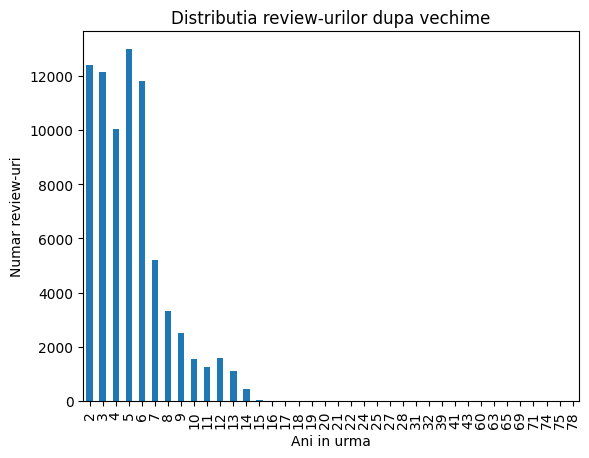

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year"] = df["Date"].dt.year
current_year = pd.Timestamp.now().year

df["years_ago"] = (current_year - df["year"])
df["years_ago"] = df["years_ago"].fillna(-1).astype(int).replace(-1, pd.NA)

print(f"Cel mai recent review: acum {df['years_ago'].min()} ani")
print(f"Cel mai vechi review: acum {df['years_ago'].max()} ani")
reviews_per_years_ago = df["years_ago"].value_counts().sort_index()
print(reviews_per_years_ago)

reviews_per_years_ago.plot(kind="bar")

plt.title("Distributia review-urilor dupa vechime")
plt.xlabel("Ani in urma")
plt.ylabel("Numar review-uri")

plt.show()

- se observa anumite inconsistente deoarece aplicatia Letterboxd a fost lansata la final de 2012, dar exista review-uri inclusiv din anul 1948, deci voi elimina aceste review-uri pastrandu-le doar pe cele incepand cu 2012.


In [ ]:
import pandas as pd

df = pd.read_csv("reviews_clean.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year"] = df["Date"].dt.year
df2 = pd.read_csv("reviews_clean.csv")
print("Randuri in dataset inainte:", len(df2))
df = df[df["year"] >= 2012]
df.to_csv("reviews_clean_final.csv", index=False)
print("Randuri in dataset dupa:", len(df))

Randuri in dataset inainte: 76467
Randuri in dataset dupa: 76329



Pentru a analiza distributia review-urilor in timp, am selectat filmul care contine cele mai multe review-uri. Apoi, am grupat datele review-urilor in functie de ani.


Deoarece setul de date este din 2024, acesta va fi anul maxim inregistrat.


Se observa o crestere semnificativa din anul 2020, fiind vizibil efectul pandemiei care a permis poate oamenilor sa aiba ocazii mai multe de a se uita la filme.



/tmp/ipykernel_2019/3939775597.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top['Date'] = pd.to_datetime(df_top['Date'])


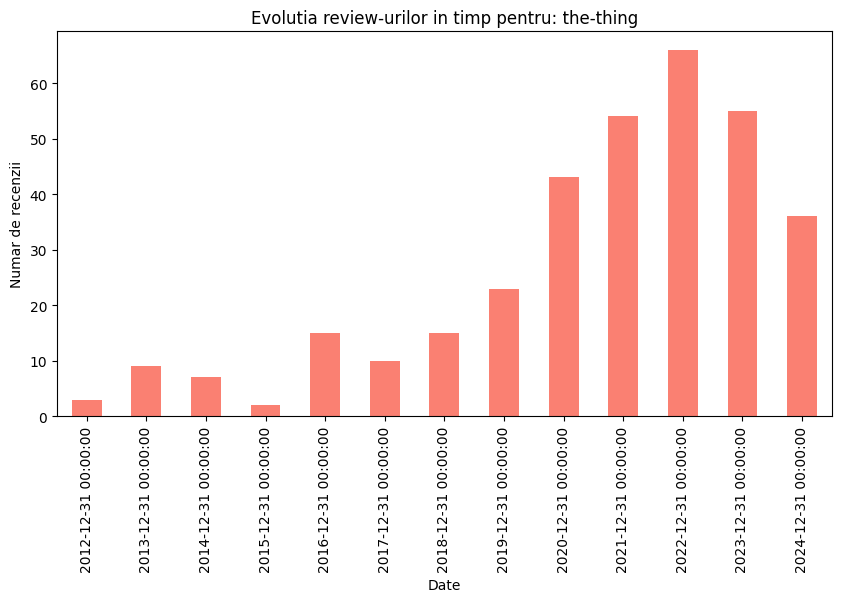

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("reviews_clean_final.csv")
top_movie = df['Movie'].value_counts().idxmax()
df_top = df[df['Movie'] == top_movie]

plt.figure(figsize=(10, 5))
# transformam data in format datetime pentru grafic
df_top['Date'] = pd.to_datetime(df_top['Date'])
df_top.resample('YE', on='Date').size().plot(kind='bar', color='salmon')
plt.title(f'Evolutia review-urilor in timp pentru: {top_movie}')
plt.ylabel('Numar de recenzii')
plt.show()

Distributia pe clase - verific daca setul este echilibrat.

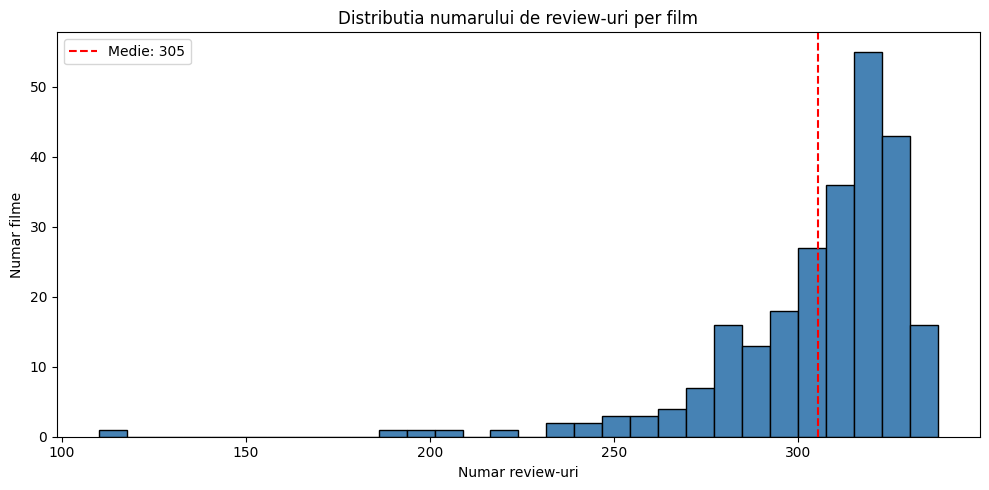

Min review-uri: 110
Max review-uri: 338
Medie: 305.3
Std: 27.5


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("reviews_clean_final.csv")

reviews_per_film = df['Movie'].value_counts()

plt.figure(figsize=(10, 5))
plt.hist(reviews_per_film.values, bins=30, color='steelblue', edgecolor='black')
plt.title('Distributia numarului de review-uri per film')
plt.xlabel('Numar review-uri')
plt.ylabel('Numar filme')
plt.axvline(reviews_per_film.mean(), color='red', linestyle='--', label=f'Medie: {reviews_per_film.mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Min review-uri: {reviews_per_film.min()}")
print(f"Max review-uri: {reviews_per_film.max()}")
print(f"Medie: {reviews_per_film.mean():.1f}")
print(f"Std: {reviews_per_film.std():.1f}")

Setul de date prezintă un echilibru relativ bun între clase, media fiind de 283 review-uri per film cu o abatere standard de doar 27.5. Toate cele 250 de filme sunt reprezentate cu minimum 110 review-uri, ceea ce indică faptul că modelul nu va fi biased semnificativ față de filmele mai populare.

**PREGATIRE PENTRU ANTRENARE**

- voi sterge coloana "Status" care contine valorile "Watched" , "Rewatched" sau N/A , deoarece valorile inconsistente pot strica rezultatele si nu este o proprietate relevanta in problema mea.
- de asemenea, elimin si coloana "language" deoarece am verificat deja ca toate review-urile sunt in engleza, deci nu mai am nevoie de acea coloana

- convertesc clasele(numele filmelor) in numere, atribuindu-le numere in ordine alfabetica.
- impart setul de date in 60% antrenare, 20% validare si 20% testare

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("reviews_clean_final.csv")

for col in ["Status", "language", "Date"]:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.dropna(subset=["Review"])
df = df[df["Review"].str.strip() != ""]
df = df.reset_index(drop=True)

le = LabelEncoder()
df["Movie_Label"] = le.fit_transform(df["Movie"])

X = df["Review"].astype(str)
y = df["Movie_Label"]

# 60% antrenare / 20% validare / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train:    {len(X_train):,}")
print(f"Validare: {len(X_val):,}")
print(f"Test:     {len(X_test):,}")
print(f"Clase:    {y.nunique()}")

Train:    45,797
Validare: 15,266
Test:     15,266
Clase:    250


## 2. Vectorizare TF-IDF

Vectorizarea se face separat. TF-IDF este antrenat exclusiv pe setul de antrenare (vocabular fixat la 30.000 de n-grame), dupa care seturile de validare si test sunt transformate cu acelasi vectorizer, fara ca acele exemple sa influenteze vocabularul.

Testam trei configuratii de n-grame:
- **(1, 1)** – unigrams
- **(1, 2)** – unigrams + bigrams
- **(1, 3)** – unigrams + bigrams + trigrams

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

MAX_FEATURES = 30_000

ngram_configs = {
    'unigrams (1,1)': (1, 1),
    'bigrams  (1,2)': (1, 2),
    'trigrams (1,3)': (1, 3),
}

vectorizers   = {}
X_train_tfidf = {}
X_val_tfidf   = {}
X_test_tfidf  = {}

for config_name, ngram_range in ngram_configs.items():
    vec = TfidfVectorizer(
        max_features=MAX_FEATURES,
        stop_words='english',
        ngram_range=ngram_range,
        sublinear_tf=True
    )
    X_train_tfidf[config_name] = vec.fit_transform(X_train)
    X_val_tfidf[config_name] = vec.transform(X_val)
    X_test_tfidf[config_name] = vec.transform(X_test)
    vectorizers[config_name] = vec

    print(f"[{config_name}] vocabular: {len(vec.vocabulary_):,} termeni | "
          f"train={X_train_tfidf[config_name].shape}, "
          f"val={X_val_tfidf[config_name].shape}, "
          f"test={X_test_tfidf[config_name].shape}")

[unigrams (1,1)] vocabular: 30,000 termeni | train=(45797, 30000), val=(15266, 30000), test=(15266, 30000)
[bigrams  (1,2)] vocabular: 30,000 termeni | train=(45797, 30000), val=(15266, 30000), test=(15266, 30000)
[trigrams (1,3)] vocabular: 30,000 termeni | train=(45797, 30000), val=(15266, 30000), test=(15266, 30000)


## 3. Naive Bayes

Pentru fiecare configuratie de n-grame antrenam un Naive Bayes Multinomial cu diferite valori ale parametrului **alpha** (Laplace smoothing). Raportam **accuracy** si **macro F1**.

### Naive Bayes – unigrams (1,1)

Naive Bayes – unigrams (1,1)
 alpha  Train Acc  Train Macro F1  Val Acc  Val Macro F1
  0.05     0.9400          0.9410   0.7050        0.7072
  0.10     0.9359          0.9366   0.7082        0.7099
  0.30     0.9212          0.9210   0.7094        0.7100
  0.50     0.9085          0.9077   0.7067        0.7070
  1.00     0.8832          0.8812   0.7009        0.7004
  2.00     0.8513          0.8476   0.6902        0.6897

Cel mai bun alpha: 0.3


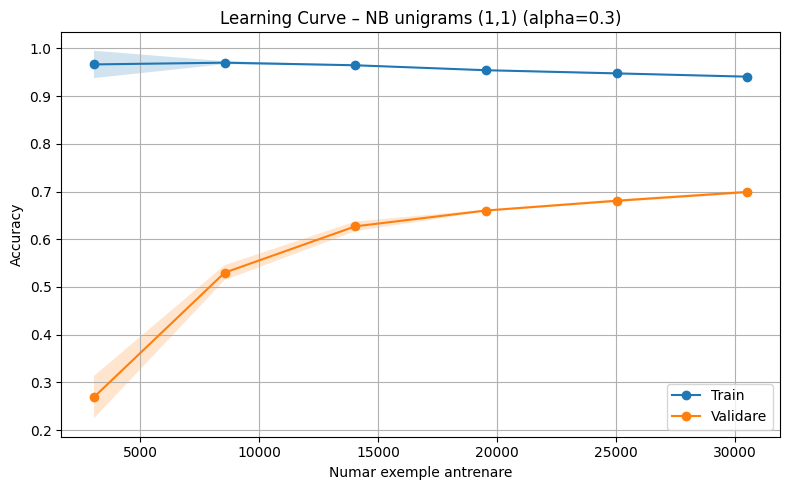

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import learning_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'unigrams (1,1)'
alphas = [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]

results_nb = []
for alpha in alphas:
    clf = MultinomialNB(alpha=alpha)
    clf.fit(X_train_tfidf[config_name], y_train)

    y_pred_train = clf.predict(X_train_tfidf[config_name])
    y_pred_val = clf.predict(X_val_tfidf[config_name])

    results_nb.append({
        'alpha':          alpha,
        'Train Acc':      round(accuracy_score(y_train, y_pred_train), 4),
        'Train Macro F1': round(f1_score(y_train, y_pred_train, average='macro', zero_division=0), 4),
        'Val Acc':        round(accuracy_score(y_val, y_pred_val), 4),
        'Val Macro F1':   round(f1_score(y_val, y_pred_val, average='macro', zero_division=0), 4),
    })

df_nb = pd.DataFrame(results_nb)
print(f"Naive Bayes – {config_name}")
print(df_nb.to_string(index=False))

best_alpha = df_nb.loc[df_nb['Val Macro F1'].idxmax(), 'alpha']
print(f"\nCel mai bun alpha: {best_alpha}")

# learning curve pentru cel mai bun alpha
best_clf = MultinomialNB(alpha=best_alpha)
train_sizes, train_scores, val_scores = learning_curve(
    best_clf,
    X_train_tfidf[config_name], y_train,
    cv=3, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2)
ax.plot(train_sizes, val_scores.mean(axis=1), marker='o', label='Validare')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
ax.set_title(f'Learning Curve – NB {config_name} (alpha={best_alpha})')
ax.set_xlabel('Numar exemple antrenare')
ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

### Naive Bayes – bigrams  (1,2)

Naive Bayes – bigrams  (1,2)
 alpha  Train Acc  Train Macro F1  Val Acc  Val Macro F1
  0.05     0.9594          0.9602   0.6953        0.6978
  0.10     0.9566          0.9572   0.7003        0.7017
  0.30     0.9436          0.9432   0.7023        0.7018
  0.50     0.9322          0.9313   0.7015        0.7007
  1.00     0.9067          0.9044   0.6971        0.6966
  2.00     0.8727          0.8686   0.6873        0.6870

Cel mai bun alpha: 0.3


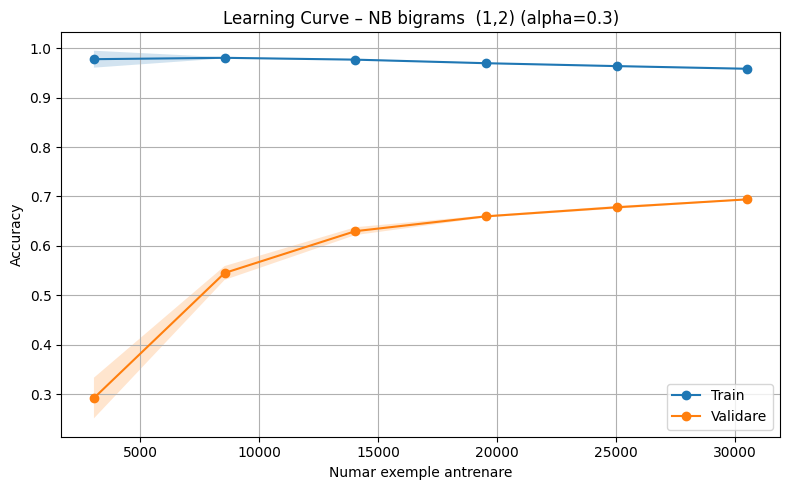

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import learning_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'bigrams  (1,2)'
alphas = [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]

results_nb = []
for alpha in alphas:
    clf = MultinomialNB(alpha=alpha)
    clf.fit(X_train_tfidf[config_name], y_train)

    y_pred_train = clf.predict(X_train_tfidf[config_name])
    y_pred_val = clf.predict(X_val_tfidf[config_name])

    results_nb.append({
        'alpha':          alpha,
        'Train Acc':      round(accuracy_score(y_train, y_pred_train), 4),
        'Train Macro F1': round(f1_score(y_train, y_pred_train, average='macro', zero_division=0), 4),
        'Val Acc':        round(accuracy_score(y_val, y_pred_val), 4),
        'Val Macro F1':   round(f1_score(y_val, y_pred_val, average='macro', zero_division=0), 4),
    })

df_nb = pd.DataFrame(results_nb)
print(f"Naive Bayes – {config_name}")
print(df_nb.to_string(index=False))

best_alpha = df_nb.loc[df_nb['Val Macro F1'].idxmax(), 'alpha']
print(f"\nCel mai bun alpha: {best_alpha}")

best_clf = MultinomialNB(alpha=best_alpha)
train_sizes, train_scores, val_scores = learning_curve(
    best_clf,
    X_train_tfidf[config_name], y_train,
    cv=3, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2)
ax.plot(train_sizes, val_scores.mean(axis=1), marker='o', label='Validare')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
ax.set_title(f'Learning Curve – NB {config_name} (alpha={best_alpha})')
ax.set_xlabel('Numar exemple antrenare')
ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

### Naive Bayes – trigrams (1,3)

Naive Bayes – trigrams (1,3)
 alpha  Train Acc  Train Macro F1  Val Acc  Val Macro F1
  0.05     0.9589          0.9596   0.6935        0.6958
  0.10     0.9560          0.9566   0.6988        0.7003
  0.30     0.9428          0.9425   0.7007        0.7003
  0.50     0.9320          0.9313   0.6995        0.6985
  1.00     0.9055          0.9032   0.6952        0.6944
  2.00     0.8718          0.8677   0.6871        0.6869

Cel mai bun alpha: 0.1


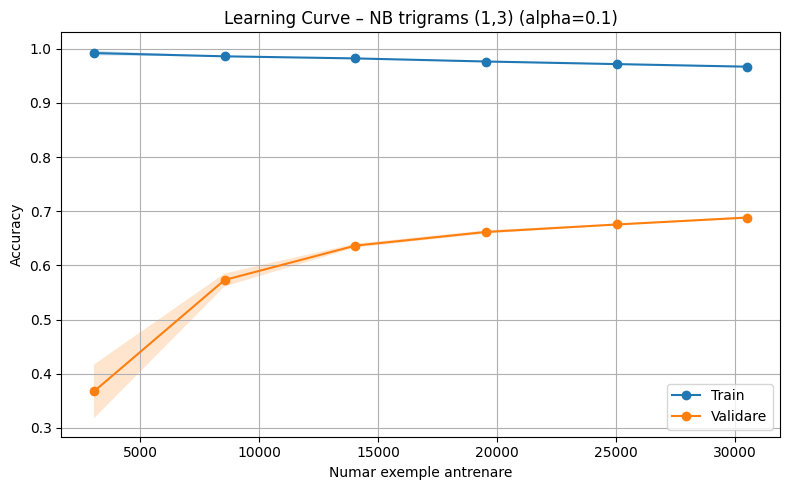

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import learning_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'trigrams (1,3)'
alphas = [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]

results_nb = []
for alpha in alphas:
    clf = MultinomialNB(alpha=alpha)
    clf.fit(X_train_tfidf[config_name], y_train)

    y_pred_train = clf.predict(X_train_tfidf[config_name])
    y_pred_val = clf.predict(X_val_tfidf[config_name])

    results_nb.append({
        'alpha':          alpha,
        'Train Acc':      round(accuracy_score(y_train, y_pred_train), 4),
        'Train Macro F1': round(f1_score(y_train, y_pred_train, average='macro', zero_division=0), 4),
        'Val Acc':        round(accuracy_score(y_val, y_pred_val), 4),
        'Val Macro F1':   round(f1_score(y_val, y_pred_val, average='macro', zero_division=0), 4),
    })

df_nb = pd.DataFrame(results_nb)
print(f"Naive Bayes – {config_name}")
print(df_nb.to_string(index=False))

best_alpha = df_nb.loc[df_nb['Val Macro F1'].idxmax(), 'alpha']
print(f"\nCel mai bun alpha: {best_alpha}")

best_clf = MultinomialNB(alpha=best_alpha)
train_sizes, train_scores, val_scores = learning_curve(
    best_clf,
    X_train_tfidf[config_name], y_train,
    cv=3, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2)
ax.plot(train_sizes, val_scores.mean(axis=1), marker='o', label='Validare')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
ax.set_title(f'Learning Curve – NB {config_name} (alpha={best_alpha})')
ax.set_xlabel('Numar exemple antrenare')
ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## 4. Regresie Logistica cu Keras

Regresia logistica este echivalenta cu un singur strat `Dense(250, activation='softmax')` aplicat direct peste vectorii TF-IDF.

Optimizatorul ales este **SGD**

In [ ]:
!pip install tensorflow -q

In [ ]:
import numpy as np
from tensorflow.keras.utils import Sequence

class SparseGenerator(Sequence):

    def __init__(self, X_sparse, y, batch_size=256, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.X = X_sparse
        self.y = np.array(y)
        self.bs = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(self.X.shape[0])
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(self.X.shape[0] / self.bs))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.bs : (idx + 1) * self.bs]
        X_batch = self.X[batch_idx].toarray().astype(np.float32)
        y_batch = self.y[batch_idx]
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

def predict_from_sparse(model, X_sparse, batch_size=512):
    n = X_sparse.shape[0]
    preds = []
    for i in range(0, n, batch_size):
        batch = X_sparse[i : i + batch_size].toarray().astype(np.float32)
        preds.append(np.argmax(model.predict(batch, verbose=0), axis=1))
    return np.concatenate(preds)

### Regresie Logistica Keras – unigrams (1,1)

lr=0.50, mom=0.0: Val Acc=0.6228, Val Macro F1=0.6251
lr=0.10, mom=0.0: Val Acc=0.4190, Val Macro F1=0.4391
lr=0.01, mom=0.0: Val Acc=0.0736, Val Macro F1=0.0589
lr=0.10, mom=0.9: Val Acc=0.6454, Val Macro F1=0.6447
lr=0.10, mom=0.9 nesterov: Val Acc=0.6456, Val Macro F1=0.6464
lr=0.01, mom=0.9 nesterov: Val Acc=0.4181, Val Macro F1=0.4397

Regresie Logistica Keras – unigrams (1,1)
                   Config  Train Acc  Train Macro F1  Val Acc  Val Macro F1
         lr=0.50, mom=0.0     0.7114          0.7106   0.6228        0.6251
         lr=0.10, mom=0.0     0.4730          0.4931   0.4190        0.4391
         lr=0.01, mom=0.0     0.0857          0.0709   0.0736        0.0589
         lr=0.10, mom=0.9     0.7412          0.7389   0.6454        0.6447
lr=0.10, mom=0.9 nesterov     0.7408          0.7394   0.6456        0.6464
lr=0.01, mom=0.9 nesterov     0.4702          0.4915   0.4181        0.4397

Cea mai buna configuratie: lr=0.10, mom=0.9 nesterov


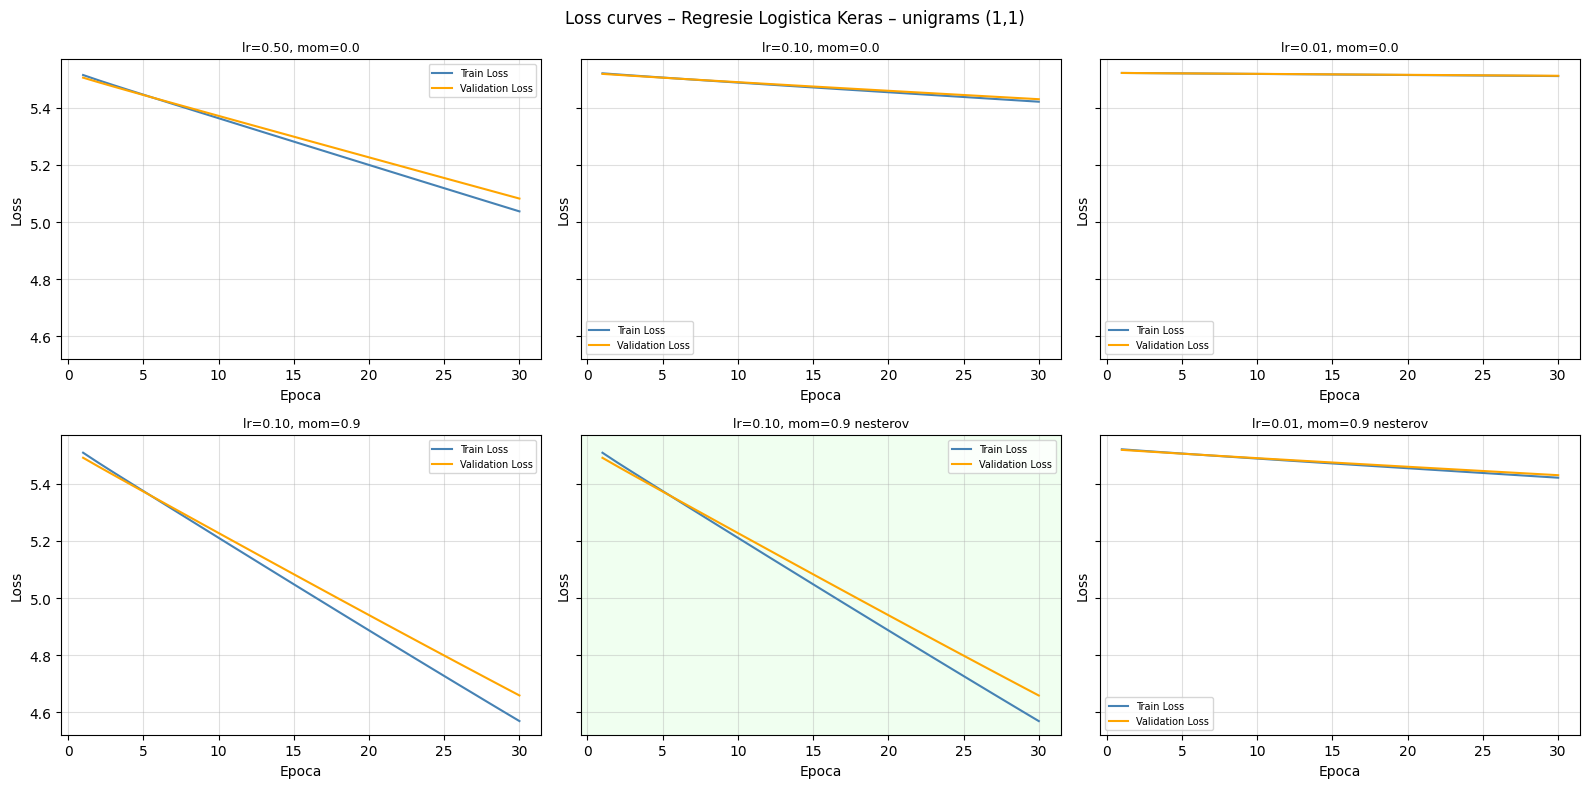

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'unigrams (1,1)'
num_classes = int(y_train.nunique())
n_features  = X_train_tfidf[config_name].shape[1]

sgd_configs = [
    {'lr': 0.50,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.50, mom=0.0'},
    {'lr': 0.10,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.10, mom=0.0'},
    {'lr': 0.01,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.01, mom=0.0'},
    {'lr': 0.10,  'momentum': 0.9, 'nesterov': False, 'label': 'lr=0.10, mom=0.9'},
    {'lr': 0.10,  'momentum': 0.9, 'nesterov': True,  'label': 'lr=0.10, mom=0.9 nesterov'},
    {'lr': 0.01,  'momentum': 0.9, 'nesterov': True,  'label': 'lr=0.01, mom=0.9 nesterov'},
]

train_gen = SparseGenerator(X_train_tfidf[config_name], y_train, batch_size=256, shuffle=True)
val_gen   = SparseGenerator(X_val_tfidf[config_name],   y_val,   batch_size=256, shuffle=False)

results_lr  = []
all_histories = {}

for cfg in sgd_configs:
    tf.random.set_seed(42)

    # Input explicit – evita deprecation warning Keras
    model_lr = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model_lr.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=cfg['lr'],
            momentum=cfg['momentum'],
            nesterov=cfg['nesterov']
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model_lr.fit(
        train_gen, validation_data=val_gen,
        epochs=30, verbose=0
    )
    all_histories[cfg['label']] = history.history

    y_pred_val   = predict_from_sparse(model_lr, X_val_tfidf[config_name])
    y_pred_train = predict_from_sparse(model_lr, X_train_tfidf[config_name])

    acc_val  = accuracy_score(y_val,   y_pred_val)
    f1_val   = f1_score(y_val,   y_pred_val,   average='macro', zero_division=0)
    acc_tr   = accuracy_score(y_train, y_pred_train)
    f1_tr    = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

    results_lr.append({
        'Config':         cfg['label'],
        'Train Acc':      round(acc_tr,  4),
        'Train Macro F1': round(f1_tr,   4),
        'Val Acc':        round(acc_val, 4),
        'Val Macro F1':   round(f1_val,  4),
    })
    print(f"{cfg['label']}: Val Acc={acc_val:.4f}, Val Macro F1={f1_val:.4f}")

df_lr = pd.DataFrame(results_lr)
print(f"\nRegresie Logistica Keras – {config_name}")
print(df_lr.to_string(index=False))

best_label = df_lr.loc[df_lr['Val Macro F1'].idxmax(), 'Config']
print(f"\nCea mai buna configuratie: {best_label}")

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for ax, cfg in zip(axes, sgd_configs):
    h = all_histories[cfg['label']]
    epochs_range = range(1, len(h['loss']) + 1)
    ax.plot(epochs_range, h['loss'],     label='Train Loss',      color='steelblue')
    ax.plot(epochs_range, h['val_loss'], label='Validation Loss',  color='orange')
    ax.set_title(cfg['label'], fontsize=9)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)
    if cfg['label'] == best_label:
        ax.set_facecolor('#f0fff0')   # fundal diferit pentru castigator

plt.suptitle(f'Loss curves – Regresie Logistica Keras – {config_name}', fontsize=12)
plt.tight_layout()
plt.show()

### Regresie Logistica Keras – bigrams  (1,2)

lr=0.50, mom=0.0 : Val Acc=0.6137, Val Macro F1=0.6186
lr=0.10, mom=0.0 : Val Acc=0.4065, Val Macro F1=0.4343
lr=0.01, mom=0.0 : Val Acc=0.0666, Val Macro F1=0.0551
lr=0.10, mom=0.9 : Val Acc=0.6429, Val Macro F1=0.6429
lr=0.10, mom=0.9 nesterov : Val Acc=0.6446, Val Macro F1=0.6462
lr=0.01, mom=0.9 nesterov : Val Acc=0.4046, Val Macro F1=0.4326

Regresie Logistica Keras – bigrams  (1,2)
                   Config  Train Acc  Train Macro F1  Val Acc  Val Macro F1
         lr=0.50, mom=0.0     0.7185          0.7182   0.6137        0.6186
         lr=0.10, mom=0.0     0.4613          0.4877   0.4065        0.4343
         lr=0.01, mom=0.0     0.0762          0.0630   0.0666        0.0551
         lr=0.10, mom=0.9     0.7563          0.7530   0.6429        0.6429
lr=0.10, mom=0.9 nesterov     0.7574          0.7549   0.6446        0.6462
lr=0.01, mom=0.9 nesterov     0.4606          0.4897   0.4046        0.4326

Cea mai buna configuratie: lr=0.10, mom=0.9 nesterov


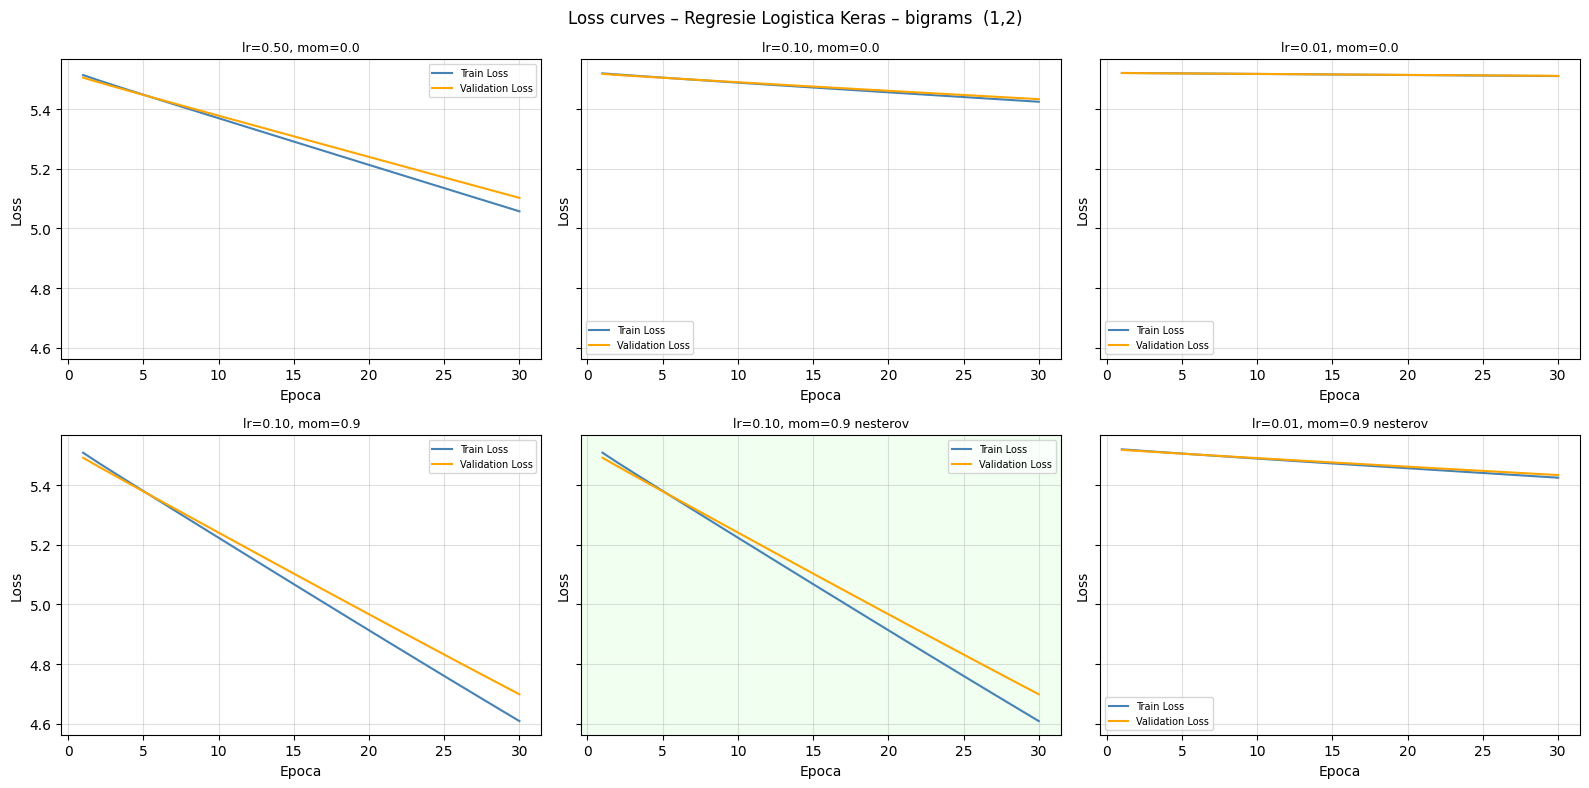

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'bigrams  (1,2)'
num_classes = int(y_train.nunique())
n_features = X_train_tfidf[config_name].shape[1]

sgd_configs = [
    {'lr': 0.50,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.50, mom=0.0'},
    {'lr': 0.10,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.10, mom=0.0'},
    {'lr': 0.01,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.01, mom=0.0'},
    {'lr': 0.10,  'momentum': 0.9, 'nesterov': False, 'label': 'lr=0.10, mom=0.9'},
    {'lr': 0.10,  'momentum': 0.9, 'nesterov': True,  'label': 'lr=0.10, mom=0.9 nesterov'},
    {'lr': 0.01,  'momentum': 0.9, 'nesterov': True,  'label': 'lr=0.01, mom=0.9 nesterov'},
]

train_gen = SparseGenerator(X_train_tfidf[config_name], y_train, batch_size=256, shuffle=True)
val_gen   = SparseGenerator(X_val_tfidf[config_name],   y_val,   batch_size=256, shuffle=False)

results_lr  = []
all_histories = {}

for cfg in sgd_configs:
    tf.random.set_seed(42)
    model_lr = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model_lr.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=cfg['lr'],
            momentum=cfg['momentum'],
            nesterov=cfg['nesterov']
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model_lr.fit(
        train_gen, validation_data=val_gen,
        epochs=30, verbose=0
    )
    all_histories[cfg['label']] = history.history

    y_pred_val = predict_from_sparse(model_lr, X_val_tfidf[config_name])
    y_pred_train = predict_from_sparse(model_lr, X_train_tfidf[config_name])

    acc_val = accuracy_score(y_val,   y_pred_val)
    f1_val = f1_score(y_val,   y_pred_val,   average='macro', zero_division=0)
    acc_tr = accuracy_score(y_train, y_pred_train)
    f1_tr = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

    results_lr.append({
        'Config':         cfg['label'],
        'Train Acc':      round(acc_tr,  4),
        'Train Macro F1': round(f1_tr,   4),
        'Val Acc':        round(acc_val, 4),
        'Val Macro F1':   round(f1_val,  4),
    })
    print(f"{cfg['label']} : Val Acc={acc_val:.4f}, Val Macro F1={f1_val:.4f}")

df_lr = pd.DataFrame(results_lr)
print(f"\nRegresie Logistica Keras – {config_name}")
print(df_lr.to_string(index=False))

best_label = df_lr.loc[df_lr['Val Macro F1'].idxmax(), 'Config']
print(f"\nCea mai buna configuratie: {best_label}")

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for ax, cfg in zip(axes, sgd_configs):
    h = all_histories[cfg['label']]
    epochs_range = range(1, len(h['loss']) + 1)
    ax.plot(epochs_range, h['loss'],     label='Train Loss',      color='steelblue')
    ax.plot(epochs_range, h['val_loss'], label='Validation Loss',  color='orange')
    ax.set_title(cfg['label'], fontsize=9)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)
    if cfg['label'] == best_label:
        ax.set_facecolor('#f0fff0')

plt.suptitle(f'Loss curves – Regresie Logistica Keras – {config_name}', fontsize=12)
plt.tight_layout()
plt.show()

### Regresie Logistica Keras – trigrams (1,3)

lr=0.50, mom=0.0: Val Acc=0.6123, Val Macro F1=0.6181
lr=0.10, mom=0.0: Val Acc=0.4056, Val Macro F1=0.4326
lr=0.01, mom=0.0: Val Acc=0.0699, Val Macro F1=0.0574
lr=0.10, mom=0.9: Val Acc=0.6415, Val Macro F1=0.6431
lr=0.10, mom=0.9 nesterov: Val Acc=0.6425, Val Macro F1=0.6438
lr=0.01, mom=0.9 nesterov: Val Acc=0.4025, Val Macro F1=0.4310

Regresie Logistica Keras – trigrams (1,3)
                   Config  Train Acc  Train Macro F1  Val Acc  Val Macro F1
         lr=0.50, mom=0.0     0.7167          0.7167   0.6123        0.6181
         lr=0.10, mom=0.0     0.4589          0.4865   0.4056        0.4326
         lr=0.01, mom=0.0     0.0788          0.0651   0.0699        0.0574
         lr=0.10, mom=0.9     0.7557          0.7538   0.6415        0.6431
lr=0.10, mom=0.9 nesterov     0.7568          0.7541   0.6425        0.6438
lr=0.01, mom=0.9 nesterov     0.4591          0.4872   0.4025        0.4310

Cea mai buna configuratie: lr=0.10, mom=0.9 nesterov


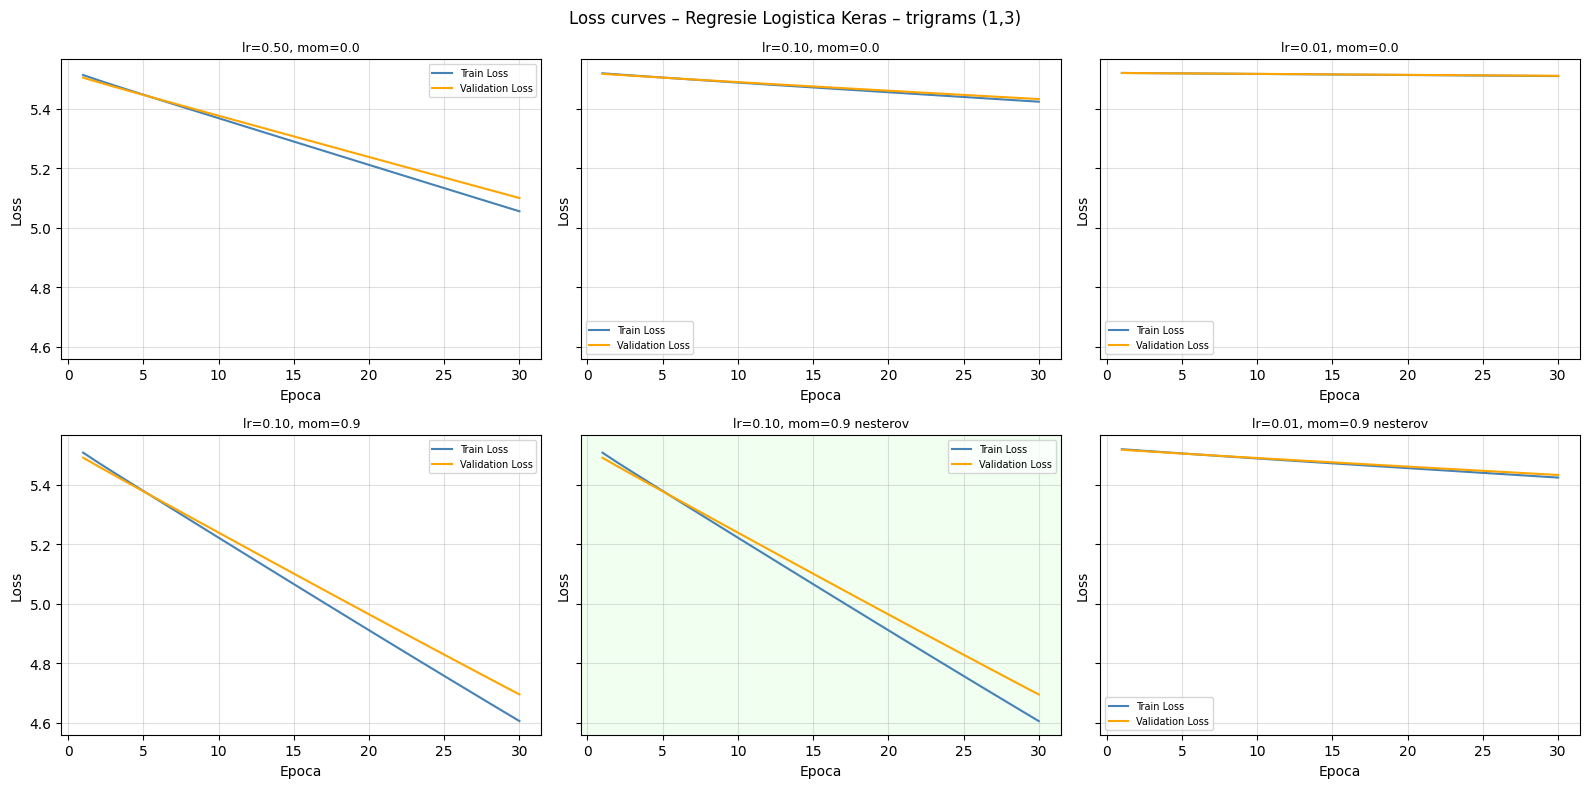

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'trigrams (1,3)'
num_classes = int(y_train.nunique())   # 250
n_features  = X_train_tfidf[config_name].shape[1]

sgd_configs = [
    {'lr': 0.50,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.50, mom=0.0'},
    {'lr': 0.10,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.10, mom=0.0'},
    {'lr': 0.01,  'momentum': 0.0, 'nesterov': False, 'label': 'lr=0.01, mom=0.0'},
    {'lr': 0.10,  'momentum': 0.9, 'nesterov': False, 'label': 'lr=0.10, mom=0.9'},
    {'lr': 0.10,  'momentum': 0.9, 'nesterov': True,  'label': 'lr=0.10, mom=0.9 nesterov'},
    {'lr': 0.01,  'momentum': 0.9, 'nesterov': True,  'label': 'lr=0.01, mom=0.9 nesterov'},
]

train_gen = SparseGenerator(X_train_tfidf[config_name], y_train, batch_size=256, shuffle=True)
val_gen = SparseGenerator(X_val_tfidf[config_name],   y_val,   batch_size=256, shuffle=False)

results_lr  = []
all_histories = {}

for cfg in sgd_configs:
    tf.random.set_seed(42)
    model_lr = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model_lr.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=cfg['lr'],
            momentum=cfg['momentum'],
            nesterov=cfg['nesterov']
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model_lr.fit(
        train_gen, validation_data=val_gen,
        epochs=30, verbose=0
    )
    all_histories[cfg['label']] = history.history

    y_pred_val   = predict_from_sparse(model_lr, X_val_tfidf[config_name])
    y_pred_train = predict_from_sparse(model_lr, X_train_tfidf[config_name])

    acc_val = accuracy_score(y_val,   y_pred_val)
    f1_val = f1_score(y_val,   y_pred_val,   average='macro', zero_division=0)
    acc_tr = accuracy_score(y_train, y_pred_train)
    f1_tr = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

    results_lr.append({
        'Config':         cfg['label'],
        'Train Acc':      round(acc_tr,  4),
        'Train Macro F1': round(f1_tr,   4),
        'Val Acc':        round(acc_val, 4),
        'Val Macro F1':   round(f1_val,  4),
    })
    print(f"{cfg['label']}: Val Acc={acc_val:.4f}, Val Macro F1={f1_val:.4f}")

df_lr = pd.DataFrame(results_lr)
print(f"\nRegresie Logistica Keras – {config_name}")
print(df_lr.to_string(index=False))

best_label = df_lr.loc[df_lr['Val Macro F1'].idxmax(), 'Config']
print(f"\nCea mai buna configuratie: {best_label}")

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for ax, cfg in zip(axes, sgd_configs):
    h = all_histories[cfg['label']]
    epochs_range = range(1, len(h['loss']) + 1)
    ax.plot(epochs_range, h['loss'],     label='Train Loss',      color='steelblue')
    ax.plot(epochs_range, h['val_loss'], label='Validation Loss',  color='orange')
    ax.set_title(cfg['label'], fontsize=9)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)
    if cfg['label'] == best_label:
        ax.set_facecolor('#f0fff0')

plt.suptitle(f'Loss curves – Regresie Logistica Keras – {config_name}', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Dense Neural Network

Intre vectorii TF-IDF si stratul final de clasificare introducem un strat Dense intermediar (ReLU) cu un numar variabil de noduri si un Dropout pentru regularizare.

### Dense NN – unigrams (1,1)

hidden=64: Val Acc=0.6615, Val Macro F1=0.6659
hidden=128: Val Acc=0.6856, Val Macro F1=0.6907
hidden=256: Val Acc=0.6934, Val Macro F1=0.7012
hidden=512: Val Acc=0.7014, Val Macro F1=0.7092

Dense NN – unigrams (1,1)
 Hidden  Train Acc  Train Macro F1  Val Acc  Val Macro F1
     64     0.7909          0.7894   0.6615        0.6659
    128     0.8384          0.8383   0.6856        0.6907
    256     0.8675          0.8685   0.6934        0.7012
    512     0.8826          0.8835   0.7014        0.7092


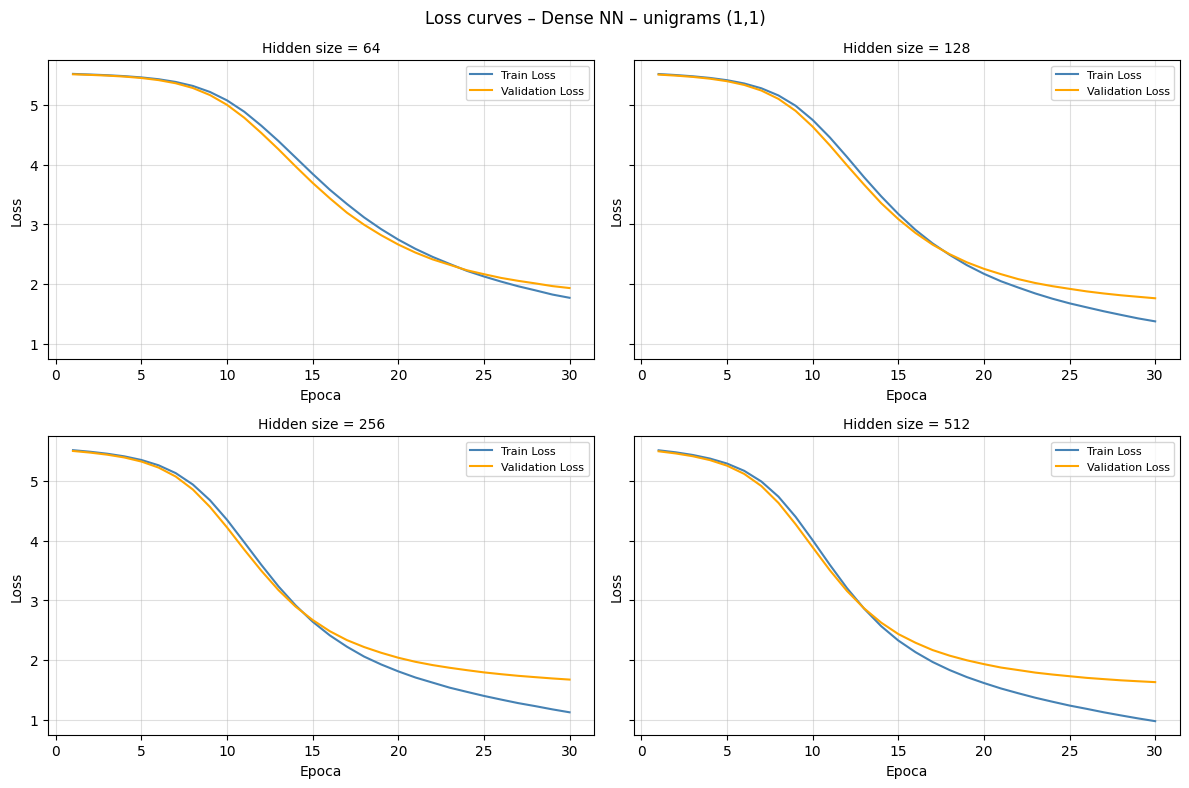

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'unigrams (1,1)'
num_classes = int(y_train.nunique())
n_features  = X_train_tfidf[config_name].shape[1]

hidden_sizes = [64, 128, 256, 512]

train_gen = SparseGenerator(X_train_tfidf[config_name], y_train, batch_size=256, shuffle=True)
val_gen   = SparseGenerator(X_val_tfidf[config_name],   y_val,   batch_size=256, shuffle=False)

results_dnn   = []
all_hist_dnn  = {}

for hidden_size in hidden_sizes:
    tf.random.set_seed(42)

    model_dnn = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(hidden_size, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model_dnn.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model_dnn.fit(train_gen, validation_data=val_gen, epochs=30, verbose=0)
    all_hist_dnn[hidden_size] = history.history

    y_pred_val = predict_from_sparse(model_dnn, X_val_tfidf[config_name])
    y_pred_train = predict_from_sparse(model_dnn, X_train_tfidf[config_name])

    acc_val = accuracy_score(y_val,   y_pred_val)
    f1_val = f1_score(y_val,   y_pred_val,   average='macro', zero_division=0)
    acc_tr = accuracy_score(y_train, y_pred_train)
    f1_tr = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

    results_dnn.append({
        'Hidden':         hidden_size,
        'Train Acc':      round(acc_tr,  4),
        'Train Macro F1': round(f1_tr,   4),
        'Val Acc':        round(acc_val, 4),
        'Val Macro F1':   round(f1_val,  4),
    })
    print(f"hidden={hidden_size}: Val Acc={acc_val:.4f}, Val Macro F1={f1_val:.4f}")

df_dnn = pd.DataFrame(results_dnn)
print(f"\nDense NN – {config_name}")
print(df_dnn.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, hs in zip(axes, hidden_sizes):
    h = all_hist_dnn[hs]
    ep = range(1, len(h['loss']) + 1)
    ax.plot(ep, h['loss'],     label='Train Loss',     color='steelblue')
    ax.plot(ep, h['val_loss'], label='Validation Loss', color='orange')
    ax.set_title(f'Hidden size = {hs}', fontsize=10)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle(f'Loss curves – Dense NN – {config_name}', fontsize=12)
plt.tight_layout()
plt.show()

### Dense NN – bigrams  (1,2)

hidden=64: Val Acc=0.6590, Val Macro F1=0.6673
hidden=128: Val Acc=0.6805, Val Macro F1=0.6865
hidden=256: Val Acc=0.6921, Val Macro F1=0.6975
hidden=512: Val Acc=0.6955, Val Macro F1=0.7043

Dense NN – bigrams  (1,2)
 Hidden  Train Acc  Train Macro F1  Val Acc  Val Macro F1
     64     0.8083          0.8071   0.6590        0.6673
    128     0.8619          0.8615   0.6805        0.6865
    256     0.8875          0.8872   0.6921        0.6975
    512     0.9022          0.9026   0.6955        0.7043


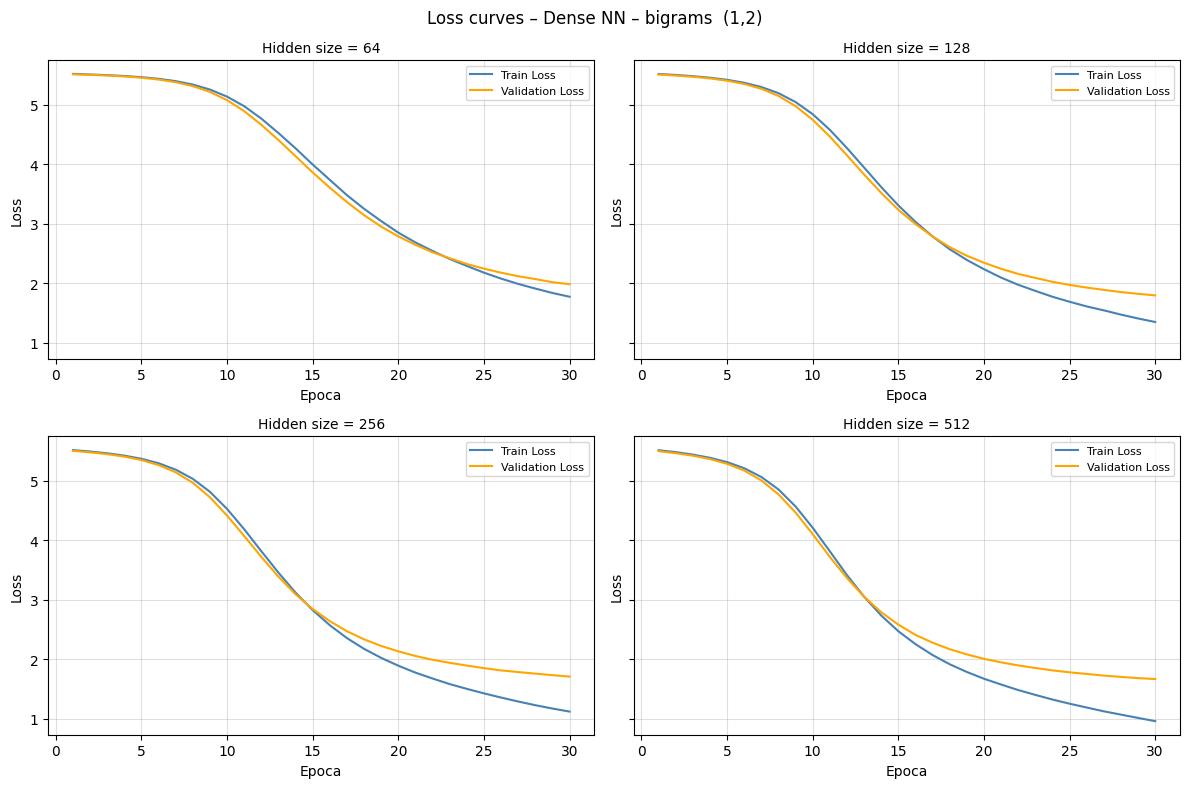

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'bigrams  (1,2)'
num_classes = int(y_train.nunique())
n_features = X_train_tfidf[config_name].shape[1]

hidden_sizes = [64, 128, 256, 512]

train_gen = SparseGenerator(X_train_tfidf[config_name], y_train, batch_size=256, shuffle=True)
val_gen = SparseGenerator(X_val_tfidf[config_name],   y_val,   batch_size=256, shuffle=False)

results_dnn = []
all_hist_dnn = {}

for hidden_size in hidden_sizes:
    tf.random.set_seed(42)

    model_dnn = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(hidden_size, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model_dnn.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model_dnn.fit(train_gen, validation_data=val_gen, epochs=30, verbose=0)
    all_hist_dnn[hidden_size] = history.history

    y_pred_val = predict_from_sparse(model_dnn, X_val_tfidf[config_name])
    y_pred_train = predict_from_sparse(model_dnn, X_train_tfidf[config_name])

    acc_val = accuracy_score(y_val,   y_pred_val)
    f1_val = f1_score(y_val,   y_pred_val,   average='macro', zero_division=0)
    acc_tr = accuracy_score(y_train, y_pred_train)
    f1_tr = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

    results_dnn.append({
        'Hidden':         hidden_size,
        'Train Acc':      round(acc_tr,  4),
        'Train Macro F1': round(f1_tr,   4),
        'Val Acc':        round(acc_val, 4),
        'Val Macro F1':   round(f1_val,  4),
    })
    print(f"hidden={hidden_size}: Val Acc={acc_val:.4f}, Val Macro F1={f1_val:.4f}")

df_dnn = pd.DataFrame(results_dnn)
print(f"\nDense NN – {config_name}")
print(df_dnn.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, hs in zip(axes, hidden_sizes):
    h = all_hist_dnn[hs]
    ep = range(1, len(h['loss']) + 1)
    ax.plot(ep, h['loss'],     label='Train Loss',     color='steelblue')
    ax.plot(ep, h['val_loss'], label='Validation Loss', color='orange')
    ax.set_title(f'Hidden size = {hs}', fontsize=10)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle(f'Loss curves – Dense NN – {config_name}', fontsize=12)
plt.tight_layout()
plt.show()

### Dense NN – trigrams (1,3)

hidden=64: Val Acc=0.6586, Val Macro F1=0.6699
hidden=128: Val Acc=0.6786, Val Macro F1=0.6877
hidden=256: Val Acc=0.6923, Val Macro F1=0.6978
hidden=512: Val Acc=0.6944, Val Macro F1=0.7025

Dense NN – trigrams (1,3)
 Hidden  Train Acc  Train Macro F1  Val Acc  Val Macro F1
     64     0.8087          0.8099   0.6586        0.6699
    128     0.8569          0.8572   0.6786        0.6877
    256     0.8884          0.8882   0.6923        0.6978
    512     0.9027          0.9029   0.6944        0.7025


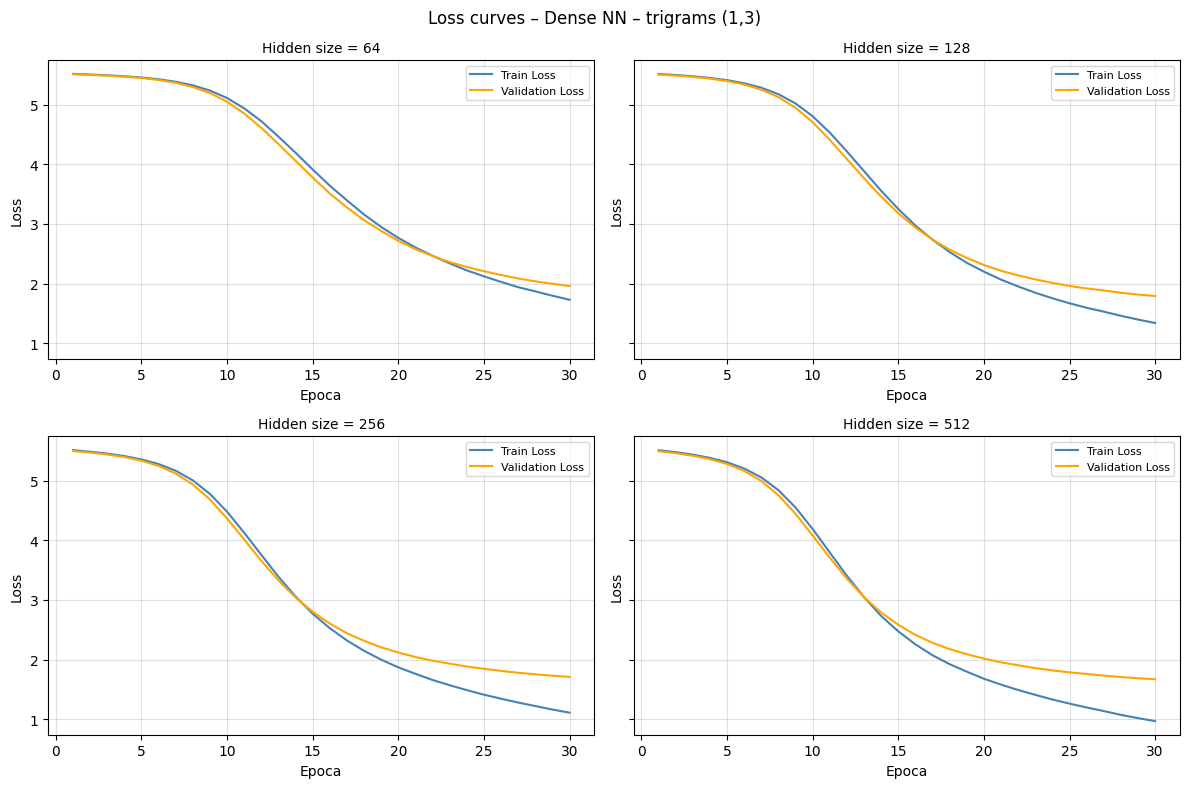

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config_name = 'trigrams (1,3)'
num_classes = int(y_train.nunique())
n_features = X_train_tfidf[config_name].shape[1]

hidden_sizes = [64, 128, 256, 512]

train_gen = SparseGenerator(X_train_tfidf[config_name], y_train, batch_size=256, shuffle=True)
val_gen = SparseGenerator(X_val_tfidf[config_name],   y_val,   batch_size=256, shuffle=False)

results_dnn = []
all_hist_dnn = {}

for hidden_size in hidden_sizes:
    tf.random.set_seed(42)

    model_dnn = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(hidden_size, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model_dnn.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model_dnn.fit(train_gen, validation_data=val_gen, epochs=30, verbose=0)
    all_hist_dnn[hidden_size] = history.history

    y_pred_val = predict_from_sparse(model_dnn, X_val_tfidf[config_name])
    y_pred_train = predict_from_sparse(model_dnn, X_train_tfidf[config_name])

    acc_val = accuracy_score(y_val,   y_pred_val)
    f1_val = f1_score(y_val,   y_pred_val,   average='macro', zero_division=0)
    acc_tr = accuracy_score(y_train, y_pred_train)
    f1_tr = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

    results_dnn.append({
        'Hidden':         hidden_size,
        'Train Acc':      round(acc_tr,  4),
        'Train Macro F1': round(f1_tr,   4),
        'Val Acc':        round(acc_val, 4),
        'Val Macro F1':   round(f1_val,  4),
    })
    print(f"hidden={hidden_size}: Val Acc={acc_val:.4f}, Val Macro F1={f1_val:.4f}")

df_dnn = pd.DataFrame(results_dnn)
print(f"\nDense NN – {config_name}")
print(df_dnn.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, hs in zip(axes, hidden_sizes):
    h = all_hist_dnn[hs]
    ep = range(1, len(h['loss']) + 1)
    ax.plot(ep, h['loss'],     label='Train Loss',     color='steelblue')
    ax.plot(ep, h['val_loss'], label='Validation Loss', color='orange')
    ax.set_title(f'Hidden size = {hs}', fontsize=10)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle(f'Loss curves – Dense NN – {config_name}', fontsize=12)
plt.tight_layout()
plt.show()

## 6. BERT Fine-tuning

Folosim `bert-base-uncased` ca encoder preantrenat. Arhitectura de clasificare construita peste BERT:

**Strategia de inghetare:** inghetam toti parametrii BERT si deschidem doar ultimul strat encoder pentru antrenare.

In [ ]:
!pip install transformers datasets accelerate -q

### Distributia lungimilor review-urilor (in cuvinte)

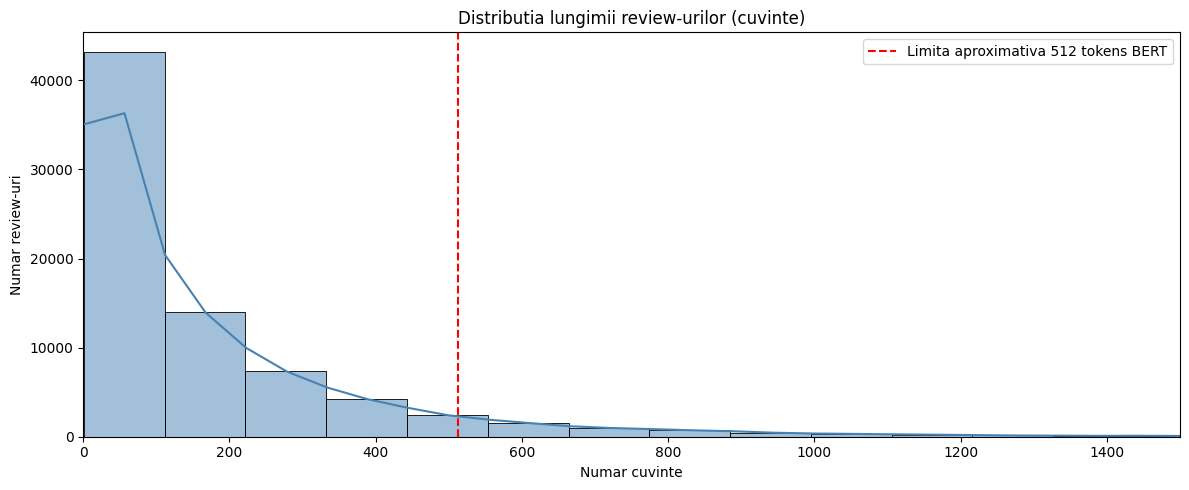

count    76329.000000
mean       176.611275
std        282.342278
min          1.000000
25%         24.000000
50%         86.000000
75%        222.000000
max      11047.000000
Name: review_len, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = pd.read_csv('reviews_clean_final.csv')
df_viz['review_len'] = df_viz['Review'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
sns.histplot(df_viz['review_len'], bins=100, color='steelblue', kde=True)
plt.axvline(x=512, color='red', linestyle='--', label='Limita aproximativa 512 tokens BERT')
plt.title('Distributia lungimii review-urilor (cuvinte)')
plt.xlabel('Numar cuvinte')
plt.ylabel('Numar review-uri')
plt.xlim(0, 1500)
plt.legend()
plt.tight_layout()
plt.show()
print(df_viz['review_len'].describe())

### Distributia in tokeni BERT

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1397 > 512). Running this sequence through the model will result in indexing errors


count    76329.000000
mean       227.464096
std        358.784150
min          3.000000
25%         34.000000
50%        112.000000
75%        286.000000
max      13805.000000
Name: token_len, dtype: float64


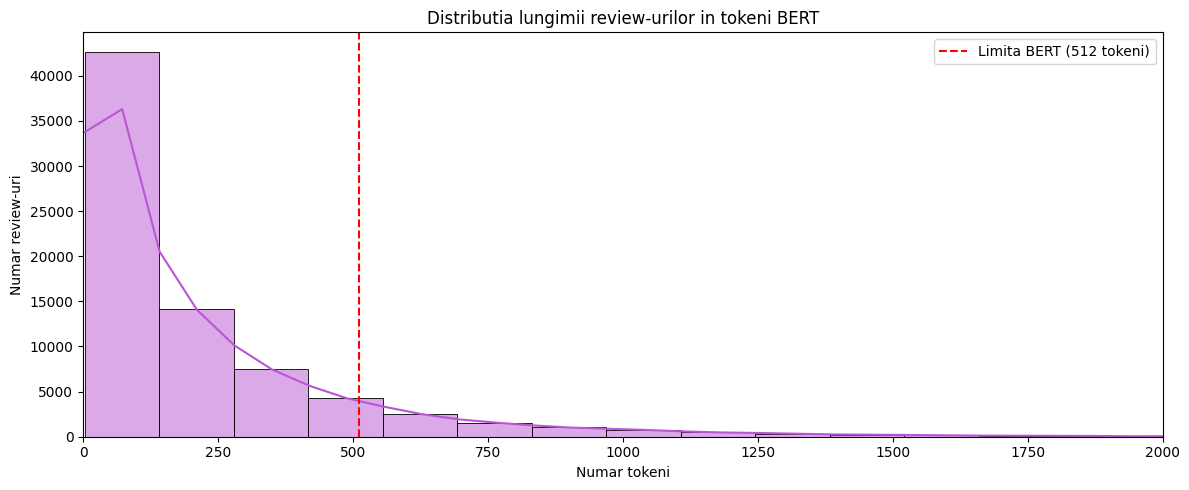

In [ ]:
from transformers import BertTokenizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = pd.read_csv('reviews_clean_final.csv')
tokenizer_viz = BertTokenizer.from_pretrained('bert-base-uncased')

df_viz['token_len'] = df_viz['Review'].astype(str).apply(
    lambda x: len(tokenizer_viz.encode(x, truncation=False))
)

print(df_viz['token_len'].describe())

plt.figure(figsize=(12, 5))
sns.histplot(df_viz['token_len'], bins=100, color='mediumorchid', kde=True)
plt.axvline(x=512, color='red', linestyle='--', label='Limita BERT (512 tokeni)')
plt.title('Distributia lungimii review-urilor in tokeni BERT')
plt.xlabel('Numar tokeni')
plt.ylabel('Numar review-uri')
plt.xlim(0, 2000)
plt.legend()
plt.tight_layout()
plt.show()

### Tokenizare si pregatire tensori

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_set(texts, max_length=512):
    return tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='pt'
    )

train_enc = tokenize_set(X_train)
val_enc = tokenize_set(X_val)
test_enc = tokenize_set(X_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_labels_t = torch.tensor(y_train.tolist())
val_labels_t = torch.tensor(y_val.tolist())
test_labels_t = torch.tensor(y_test.tolist())

train_dataset = TensorDataset(train_enc['input_ids'], train_enc['attention_mask'], train_labels_t)
val_dataset = TensorDataset(val_enc['input_ids'],   val_enc['attention_mask'],   val_labels_t)
test_dataset = TensorDataset(test_enc['input_ids'],  test_enc['attention_mask'],  test_labels_t)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 2863
Val batches:   955
Test batches:  955


### Arhitectura BertClassifier

Definim un modul PyTorch explicit, astfel incat arhitectura sa fie transparenta si vizibila prin `print(model)`.

In [ ]:
from transformers import BertModel
import torch
import torch.nn as nn


class BertClassifier(nn.Module):

    def __init__(self, num_classes=250, dropout_rate=0.3, unfreeze_last_n=1):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # Inghetam toti parametrii BERT
        for param in self.bert.parameters():
            param.requires_grad = False

        # Deschidem ultimele unfreeze_last_n straturi encoder
        n_layers = len(self.bert.encoder.layer)
        for layer_idx in range(n_layers - unfreeze_last_n, n_layers):
            for param in self.bert.encoder.layer[layer_idx].parameters():
                param.requires_grad = True

        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits


num_classes_bert = y_train.nunique()
bert_model = BertClassifier(num_classes=num_classes_bert, dropout_rate=0.3, unfreeze_last_n=1)

print(bert_model)

total_params = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"\nTotal parametri:      {total_params:,}")
print(f"Parametri antrenabili:{trainable_params:,}")
print(f"Parametri inghetati:  {total_params - trainable_params:,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

bert_model = bert_model.to(device)

Device: cuda


In [ ]:
import torch

optimizer_bert = torch.optim.AdamW([
    {
        'params': bert_model.bert.encoder.layer[11].parameters(),
        'lr': 2e-5,
        'weight_decay': 0.01
    },
    {
        'params': bert_model.dropout.parameters(),
        'lr': 1e-4,
        'weight_decay': 0.0
    },
    {
        'params': bert_model.classifier.parameters(),
        'lr': 1e-4,
        'weight_decay': 0.01
    },
])

criterion_bert = torch.nn.CrossEntropyLoss()
print("Optimizer cu discriminative fine-tuning:")
for i, group in enumerate(optimizer_bert.param_groups):
    n_params = sum(p.numel() for p in group['params'] if p.requires_grad)
    print(f"  Grup {i}: lr={group['lr']}, parametri antrenabili={n_params:,}")

Optimizer cu discriminative fine-tuning:
  Grup 0: lr=2e-05, parametri antrenabili=7,087,872
  Grup 1: lr=0.0001, parametri antrenabili=0
  Grup 2: lr=0.0001, parametri antrenabili=192,250


### Antrenare BERT

In [ ]:
import torch
import numpy as np
import time
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

train_losses_bert = []
val_losses_bert = []
val_f1_bert = []
best_val_f1_bert = 0
EPOCHS = 3

for epoch in range(EPOCHS):
    start = time.time()
    print(f"\ Epoch {epoch + 1}/{EPOCHS}")
    bert_model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc="Training"):
        ids = batch[0].to(device)
        mask = batch[1].to(device)
        lbl = batch[2].to(device)

        optimizer_bert.zero_grad()
        logits = bert_model(input_ids=ids, attention_mask=mask)
        loss = criterion_bert(logits, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer_bert.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses_bert.append(avg_train_loss)
    bert_model.eval()
    total_val_loss = 0
    preds_all, true_all = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validare"):
            ids = batch[0].to(device)
            mask = batch[1].to(device)
            lbl = batch[2].to(device)

            logits = bert_model(input_ids=ids, attention_mask=mask)
            loss = criterion_bert(logits, lbl)
            total_val_loss += loss.item()

            preds_all.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true_all.extend(lbl.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses_bert.append(avg_val_loss)

    acc_val = accuracy_score(true_all, preds_all)
    f1_macro = f1_score(true_all, preds_all, average='macro', zero_division=0)
    val_f1_bert.append(f1_macro)

    if f1_macro > best_val_f1_bert:
        best_val_f1_bert = f1_macro
        torch.save(bert_model.state_dict(), "best_bert_model.pt")
        print(" Model salvat!")

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val Accuracy: {acc_val:.4f} | Val Macro F1: {f1_macro:.4f}")
    print(f"Timp epoca: {time.time() - start:.1f}s")

<>:15: SyntaxWarning: invalid escape sequence '\ '
<>:15: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_3419/3120494659.py:15: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Epoch {epoch + 1}/{EPOCHS}")


\ Epoch 1/3


Validare: 100%|██████████| 955/955 [07:53<00:00,  2.02it/s]


 Model salvat!
Train Loss: 4.1307 | Val Loss: 2.7094
Val Accuracy: 0.4685 | Val Macro F1: 0.4669
Timp epoca: 2152.0s
\ Epoch 2/3


Validare: 100%|██████████| 955/955 [07:52<00:00,  2.02it/s]


 Model salvat!
Train Loss: 2.5103 | Val Loss: 2.1105
Val Accuracy: 0.5670 | Val Macro F1: 0.5726
Timp epoca: 2162.2s
\ Epoch 3/3


Validare: 100%|██████████| 955/955 [07:53<00:00,  2.02it/s]


 Model salvat!
Train Loss: 2.0527 | Val Loss: 1.9136
Val Accuracy: 0.6026 | Val Macro F1: 0.6091
Timp epoca: 2158.8s


## 7. Model final – antrenare pe train+validare, evaluare pe test

Dupa ce comparam toate metodele pe setul de validare si identificam cea mai buna combinatie (arhitectura + parametri), antrenam modelul respectiv pe **train + validare** combinat si il evaluam **o singura data** pe setul de test.

Setul de test nu a fost folosit in niciun pas anterior.

Structura de mai jos ilustreaza fluxul pentru **Naive Bayes** (cel mai simplu de reprodus); acelasi principiu se aplica si pentru Keras / BERT, substituind vectorizerul si clasificatorul corespunzator.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

BEST_NGRAM = (1, 1)
BEST_ALPHA = 0.3

X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)
vec_final = TfidfVectorizer(
    max_features=30_000,
    stop_words='english',
    ngram_range=BEST_NGRAM,
    sublinear_tf=True
)
X_trainval_tfidf = vec_final.fit_transform(X_trainval)
X_test_tfidf_final = vec_final.transform(X_test)

final_model = MultinomialNB(alpha=BEST_ALPHA)
final_model.fit(X_trainval_tfidf, y_trainval)

# Evaluare pe test
y_test_pred = final_model.predict(X_test_tfidf_final)

acc_test = accuracy_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

print("EVALUARE FINALA PE TEST")
print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test Macro F1: {f1_test:.4f}")

EVALUARE FINALA PE TEST
Test Accuracy: 0.7172
Test Macro F1: 0.7195


Acuratete per film

In [ ]:
import pandas as pd

rezultate_per_film = []

for label in sorted(y_test.unique()):
    film_name = le.inverse_transform([label])[0]
    mask = y_test.values == label
    total = mask.sum()
    correct = (y_test_pred[mask] == label).sum()
    accuracy_pf = correct / total * 100 if total > 0 else 0

    rezultate_per_film.append({
        'Film': film_name,
        'Total test': total,
        'Corecte': correct,
        'Accuracy %': round(accuracy_pf, 1)
    })

df_per_film = pd.DataFrame(rezultate_per_film).sort_values('Accuracy %', ascending=False)

print(f"Acuratete per film (total {len(df_per_film)} filme):\n")
print(df_per_film.to_string(index=False))

print(f"\nFilme cu accuracy 100%: {(df_per_film['Accuracy %'] == 100).sum()}")
print(f"Filme cu accuracy 0%:   {(df_per_film['Accuracy %'] == 0).sum()}")
print(f"Medie accuracy per film: {df_per_film['Accuracy %'].mean():.1f}%")

Acuratete per film (total 250 filme):

                                                              Film  Total test  Corecte  Accuracy %
                                  the-treasure-of-the-sierra-madre          65       62        95.4
                                                    malcolm-x-1992          66       62        93.9
                                                       sherlock-jr          63       58        92.1
                                         terminator-2-judgment-day          63       58        92.1
                                               anatomy-of-a-murder          63       57        90.5
                                        a-matter-of-life-and-death          67       60        89.6
                                                           tampopo          65       58        89.2
                                                memories-of-murder          65       58        89.2
                                               fanny-and-alex

## 8. Recomandari cu Cosine Similarity

Modelul de recomandare va folosi reprezentarile TF-IDF (sau BERT, dupa selectia modelului final) pentru a calcula similitudinea cosinus intre un review nou si profilul mediu al fiecarui film.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import numpy as np
import pandas as pd

df_rec = pd.read_csv("reviews_clean_final.csv")
df_rec = df_rec.dropna(subset=['Review'])
df_rec = df_rec[df_rec['Review'].str.strip() != '']

film_profiles = {}

for film in df_rec['Movie'].unique():
    reviews_film = df_rec[df_rec['Movie'] == film]['Review'].astype(str).tolist()
    vecs = vec_final.transform(reviews_film)
    vecs_norm = normalize(vecs, norm='l2')
    profil = np.asarray(vecs_norm.mean(axis=0)).flatten()
    film_profiles[film] = profil

film_names = list(film_profiles.keys())
film_matrix = normalize(np.vstack([film_profiles[f] for f in film_names]), norm='l2')

print(f"Profiluri construite: {len(film_names)} filme, matrice {film_matrix.shape}")

def recomanda_filme(review_nou, top_n=3):
    vec_review = vec_final.transform([review_nou])
    vec_norm = normalize(vec_review, norm='l2')
    vec_dense = np.asarray(vec_norm.toarray()).reshape(1, -1)
    sims = cosine_similarity(vec_dense, film_matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_n]
    return [(film_names[i], round(float(sims[i]), 4)) for i in top_idx]


review_test_nou = """
A slow-burning crime thriller with incredible tension.
The director uses silence and shadows masterfully,
and the performances are understated yet devastating.
Every frame feels deliberate.
"""

print("\nRecomandari:")
for film, score in recomanda_filme(review_test_nou, top_n=3):
    print(f" {score:.4f}  {film}")

Profiluri construite: 250 filme, matrice (250, 30000)

Recomandari:
 0.1334  army-of-shadows
 0.1148  z
 0.1070  cure


## Analiza erorilor – Matrice de confuzie

Top 20 perechi confundate:
                                       Film Real                                      Film Prezis  Confuzii
                                   the-godfather                            the-godfather-part-ii        15
            the-lord-of-the-rings-the-two-towers the-lord-of-the-rings-the-fellowship-of-the-ring        11
            the-lord-of-the-rings-the-two-towers     the-lord-of-the-rings-the-return-of-the-king        10
                                        sorcerer                                the-wages-of-fear        10
              spider-man-across-the-spider-verse                 spider-man-into-the-spider-verse        10
the-lord-of-the-rings-the-fellowship-of-the-ring             the-lord-of-the-rings-the-two-towers         9
                          werckmeister-harmonies                                       satantango         9
                             an-autumn-afternoon                                      tokyo-story         9
 

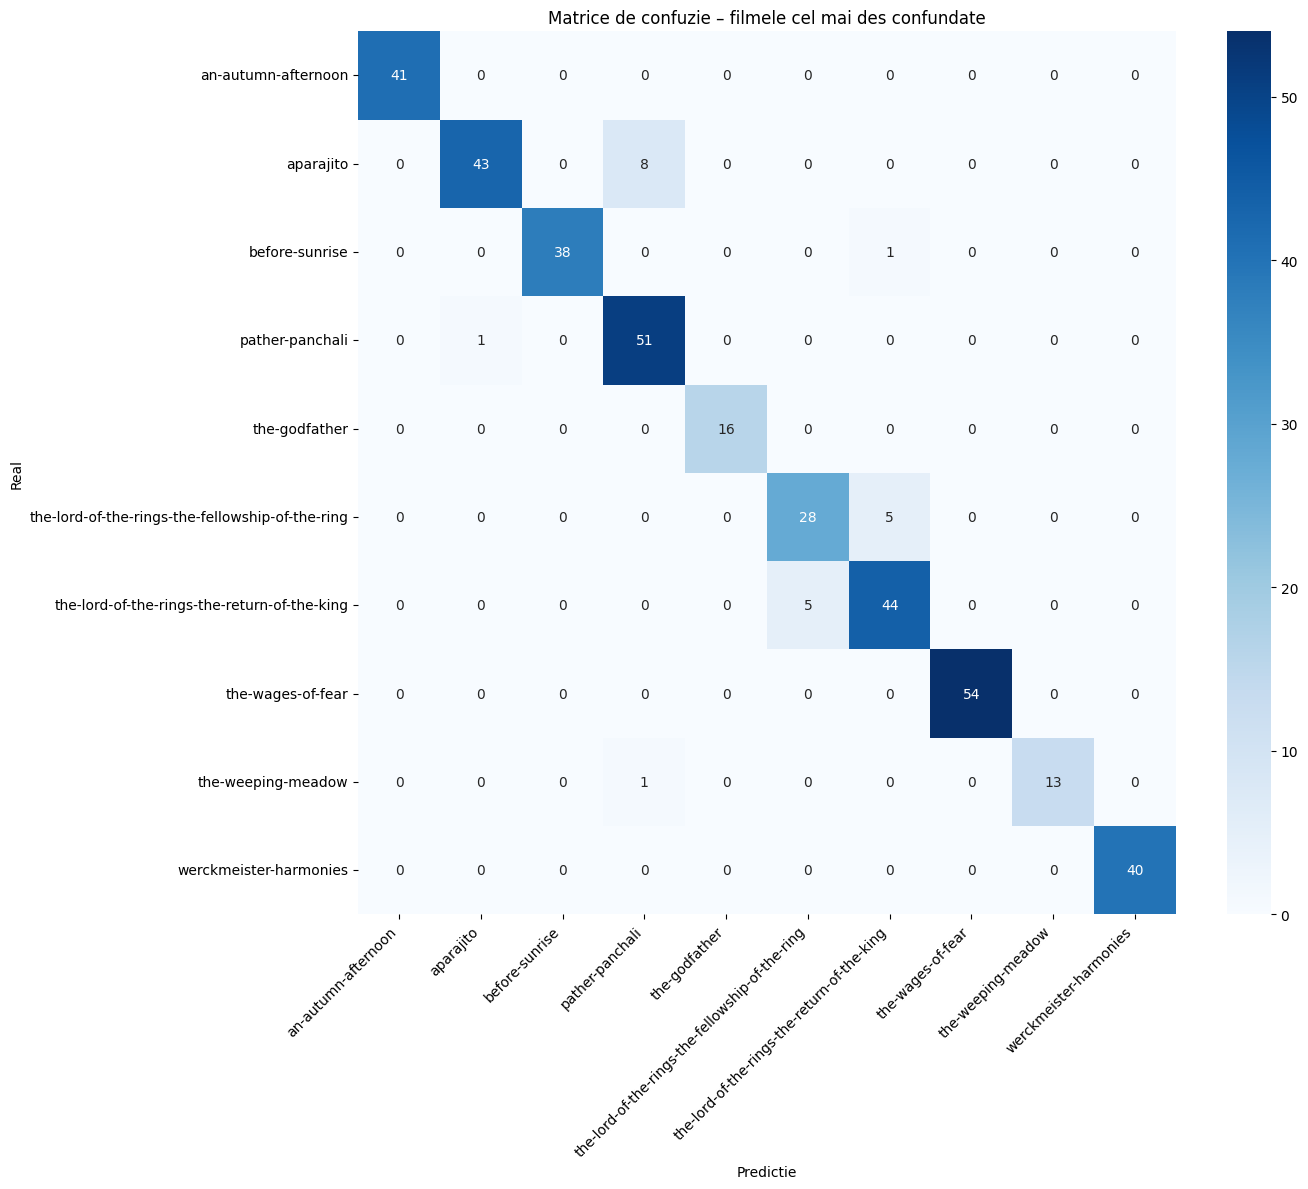

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

cm_full = confusion_matrix(y_test, y_test_pred)
cm_no_diag = cm_full.copy()
np.fill_diagonal(cm_no_diag, 0)

confuzii = []
for i in range(len(cm_no_diag)):
    for j in range(len(cm_no_diag)):
        if cm_no_diag[i, j] > 0:
            confuzii.append({
                "Film Real":  le.inverse_transform([i])[0],
                "Film Prezis":le.inverse_transform([j])[0],
                "Confuzii":   cm_no_diag[i, j]
            })

df_confuzii = pd.DataFrame(confuzii).sort_values("Confuzii", ascending=False).head(20)
print("Top 20 perechi confundate:")
print(df_confuzii.to_string(index=False))

filme_set = list(set(df_confuzii["Film Real"].tolist() + df_confuzii["Film Prezis"].tolist()))[:10]
labels_set = sorted(le.transform(filme_set))
filme_sorted = le.inverse_transform(labels_set)

mask = np.isin(y_test.values, labels_set)
cm_sub = confusion_matrix(y_test[mask], y_test_pred[mask], labels=labels_set)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues',
            xticklabels=filme_sorted, yticklabels=filme_sorted)
plt.title('Matrice de confuzie – filmele cel mai des confundate')
plt.xlabel('Predictie'); plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Matrice binara si curba ROC pentru un film ales

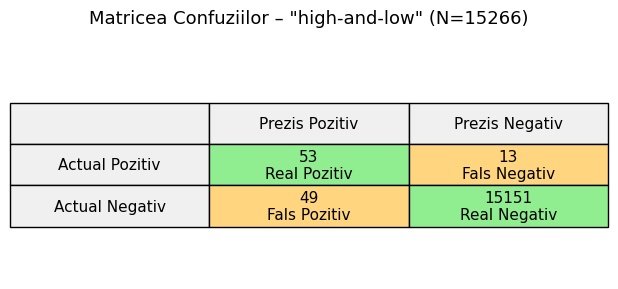

F1-Score pentru 'high-and-low': 0.6310


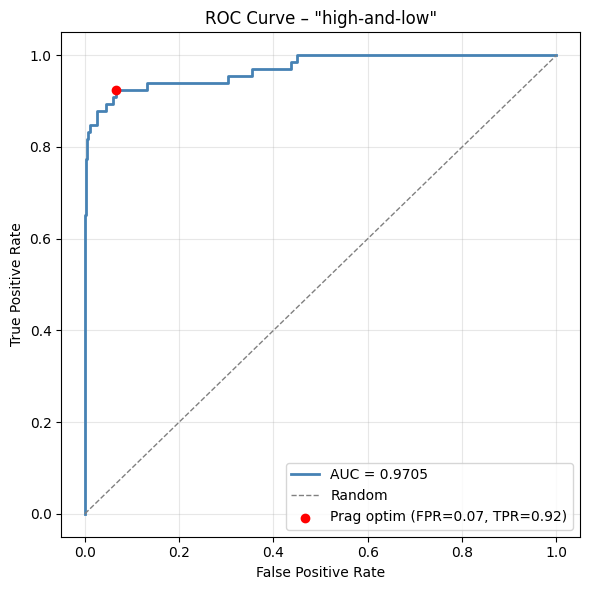

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

film_ales = "high-and-low"
film_label = le.transform([film_ales])[0]

y_test_binary = (y_test.values == film_label).astype(int)
y_pred_binary = (y_test_pred  == film_label).astype(int)

TP = int(((y_test_binary == 1) & (y_pred_binary == 1)).sum())
FP = int(((y_test_binary == 0) & (y_pred_binary == 1)).sum())
FN = int(((y_test_binary == 1) & (y_pred_binary == 0)).sum())
TN = int(((y_test_binary == 0) & (y_pred_binary == 0)).sum())
N  = TP + FP + FN + TN

fig, ax = plt.subplots(figsize=(7, 3))
ax.axis('off')
data = [
    ["",              "Prezis Pozitiv",  "Prezis Negativ"],
    ["Actual Pozitiv", f"{TP}\nReal Pozitiv",  f"{FN}\nFals Negativ"],
    ["Actual Negativ", f"{FP}\nFals Pozitiv", f"{TN}\nReal Negativ"],
]
table = ax.table(cellText=data, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.5, 2.5)
for r, c, col in [(0,0,'#f0f0f0'),(0,1,'#f0f0f0'),(0,2,'#f0f0f0'),(1,0,'#f0f0f0'),(2,0,'#f0f0f0')]:
    table[r,c].set_facecolor(col)
table[1,1].set_facecolor('#90EE90'); table[2,2].set_facecolor('#90EE90')
table[1,2].set_facecolor('#FFD580'); table[2,1].set_facecolor('#FFD580')
plt.title(f'Matricea Confuziilor – "{film_ales}" (N={N})', fontsize=13, pad=20)
plt.tight_layout(); plt.show()

f1_bin = 2*TP / (2*TP + FP + FN) if (2*TP + FP + FN) > 0 else 0
print(f"F1-Score pentru '{film_ales}': {f1_bin:.4f}")

# ROC
y_proba = final_model.predict_proba(X_test_tfidf_final)[:, film_label]
fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--', color='gray', lw=1, label="Random")
optimal_idx = np.argmax(tpr - fpr)
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', zorder=5,
            label=f"Prag optim (FPR={fpr[optimal_idx]:.2f}, TPR={tpr[optimal_idx]:.2f})")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f'ROC Curve – "{film_ales}"')
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Salvare model final

In [ ]:
import joblib

joblib.dump(final_model, "best_model_final.pkl")
joblib.dump(vec_final, "tfidf_final.pkl")
joblib.dump(le, "label_encoder_final.pkl")

['label_encoder_final.pkl']

In [ ]:
import joblib
import numpy as np

np.save("film_matrix.npy", film_matrix)
joblib.dump(film_names, "film_names.pkl")

['film_names.pkl']